In [1]:
import pandas as pd
import matplotlib.pyplot as plt

income_df = pd.read_csv('data/cleaned/income.csv')
house_price_df = pd.read_csv('data/cleaned/ejendomsdata.csv')

In [2]:
long_df = house_price_df.melt(
    id_vars="kommune",
    var_name="quarter",
    value_name="price"
)

long_df["year"] = long_df["quarter"].str[:4].astype(int)
long_df["q"] = long_df["quarter"].str[-1].astype(int)
long_df["time"] = long_df["year"] + (long_df["q"] - 1) / 4

avg_prices_yearly = (
    long_df
    .groupby("year")["price"]
    .mean()
    .reset_index()
    .rename(columns={"price": "avg_price"})
)

avg_prices_yearly.head()

,year,avg_price
0,1992,4211.399478
1,1993,4270.184896
2,1994,4544.742188
3,1995,4833.433420
4,1996,5404.206186


In [3]:
avg_income_yearly = (
    income_df
    .groupby("år", as_index=False)["income"]
    .mean()
    .rename(columns={"år": "year", "income": "avg_income"})
)

avg_income_yearly.head()

,year,avg_income
0,1992,156209.091837
1,1993,158996.897959
2,1994,168918.459184
3,1995,176261.622449
4,1996,182481.520408


In [4]:
avg_prices_yearly = (
    long_df
    .groupby("year", as_index=False)["price"]
    .mean()
    .rename(columns={"price": "avg_price"})
)

plot_df = avg_prices_yearly.merge(
    avg_income_yearly,
    on="year",
    how="inner"
)

base_year = 1992

base_price = plot_df.loc[plot_df["year"] == base_year, "avg_price"].iloc[0]
base_income = plot_df.loc[plot_df["year"] == base_year, "avg_income"].iloc[0]

plot_df["price_change_pct"] = (plot_df["avg_price"] / base_price - 1) * 100
plot_df["income_change_pct"] = (plot_df["avg_income"] / base_income - 1) * 100

plot_df.head()

,year,avg_price,avg_income,price_change_pct,income_change_pct
0,1992,4211.399478,156209.091837,0.000000,0.000000
1,1993,4270.184896,158996.897959,1.395864,1.784663
2,1994,4544.742188,168918.459184,7.915248,8.136125
3,1995,4833.433420,176261.622449,14.770243,12.836980
4,1996,5404.206186,182481.520408,28.323286,16.818758


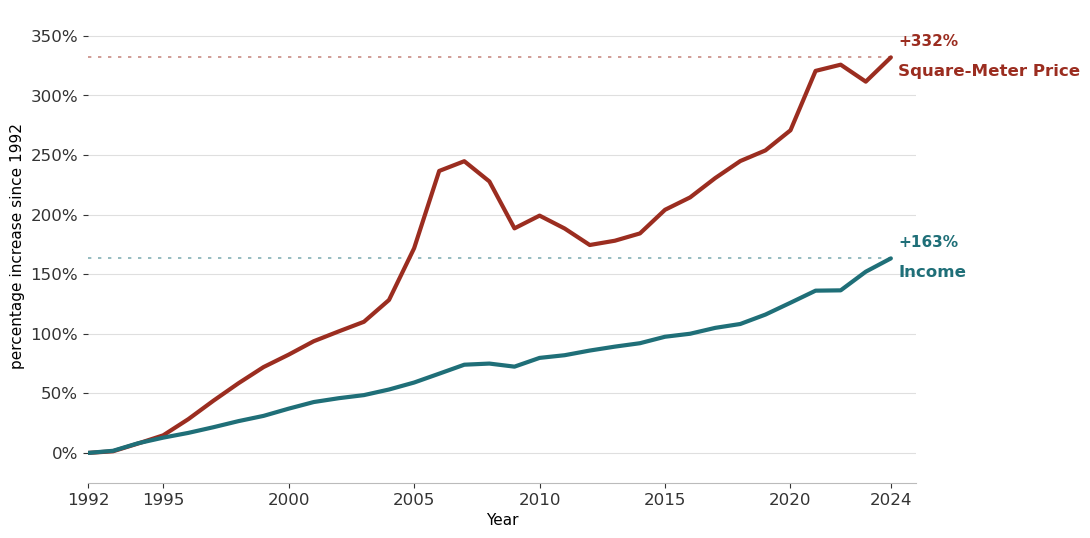

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Colors
price_color = "#9B2D20"    
income_color = "#1F6F78"   
grid_color = "#D8D8D8"
text_color = "#222222"
muted_text = "#666666"

fig, ax = plt.subplots(figsize=(11, 6.3))


ax.plot(
    plot_df["year"],
    plot_df["price_change_pct"],
    color=price_color,
    linewidth=3,
    label="Average square meter price",
    solid_capstyle="round",
    zorder=3
)

ax.plot(
    plot_df["year"],
    plot_df["income_change_pct"],
    color=income_color,
    linewidth=3,
    label="Average income before tax",
    solid_capstyle="round",
    zorder=3
)

# Direct line labels and endpoint values
latest_year = plot_df["year"].max()
latest = plot_df.loc[plot_df["year"] == latest_year].iloc[0]

price_end = latest["price_change_pct"]
income_end = latest["income_change_pct"]

# Horizontal endpoint reference lines
ax.hlines(
    y=price_end,
    xmin=plot_df["year"].min(),
    xmax=latest_year,
    color=price_color,
    linewidth=1.2,
    linestyle=(0, (2, 4)),
    alpha=0.55,
    zorder=1
)

ax.hlines(
    y=income_end,
    xmin=plot_df["year"].min(),
    xmax=latest_year,
    color=income_color,
    linewidth=1.2,
    linestyle=(0, (2, 4)),
    alpha=0.55,
    zorder=1
)

# Value labels
ax.text(
    latest_year + 0.3,
    price_end + 13,
    f"+{price_end:.0f}%",
    color=price_color,
    fontsize=11,
    fontweight="bold",
    va="center"
)

ax.text(
    latest_year + 0.3,
    income_end + 13,
    f"+{income_end:.0f}%",
    color=income_color,
    fontsize=11,
    fontweight="bold",
    va="center"
)

# Series labels
ax.text(
    latest_year + 0.3,
    price_end - 12,
    "Square-Meter Price",
    color=price_color,
    fontsize=12,
    fontweight="bold",
    va="center"
)

ax.text(
    latest_year + 0.3,
    income_end - 12,
    "Income",
    color=income_color,
    fontsize=12,
    fontweight="bold",
    va="center"
)

# Axes
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("percentage increase since 1992", fontsize=11)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

ax.set_xlim(plot_df["year"].min(), 2025)
ax.set_xticks([1992,1995, 2000, 2005, 2010, 2015, 2020, 2024])

ymax = max(plot_df["price_change_pct"].max(), plot_df["income_change_pct"].max())
ax.set_ylim(-25, ymax * 1.12)

# Grid and spines
ax.grid(axis="y", color=grid_color, linewidth=0.8, alpha=0.8)
ax.grid(axis="x", visible=False)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#BBBBBB")
ax.tick_params(axis="both", labelsize=12, colors="#333333")

ax.legend().remove()

plt.tight_layout(rect=[0, 0.05, 1, 0.92])

#save the plot
plt.savefig("output/price_income_trends.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# affordability calculation
plot_df["annual_incomes_for_100sqm"] = (
    100 * plot_df["avg_price"] / plot_df["avg_income"]
)

plot_df[["year", "avg_price", "avg_income", "annual_incomes_for_100sqm"]].head()

,year,avg_price,avg_income,annual_incomes_for_100sqm
0,1992,4211.399478,156209.091837,2.696002
1,1993,4270.184896,158996.897959,2.685703
2,1994,4544.742188,168918.459184,2.690495
3,1995,4833.433420,176261.622449,2.742193
4,1996,5404.206186,182481.520408,2.961509


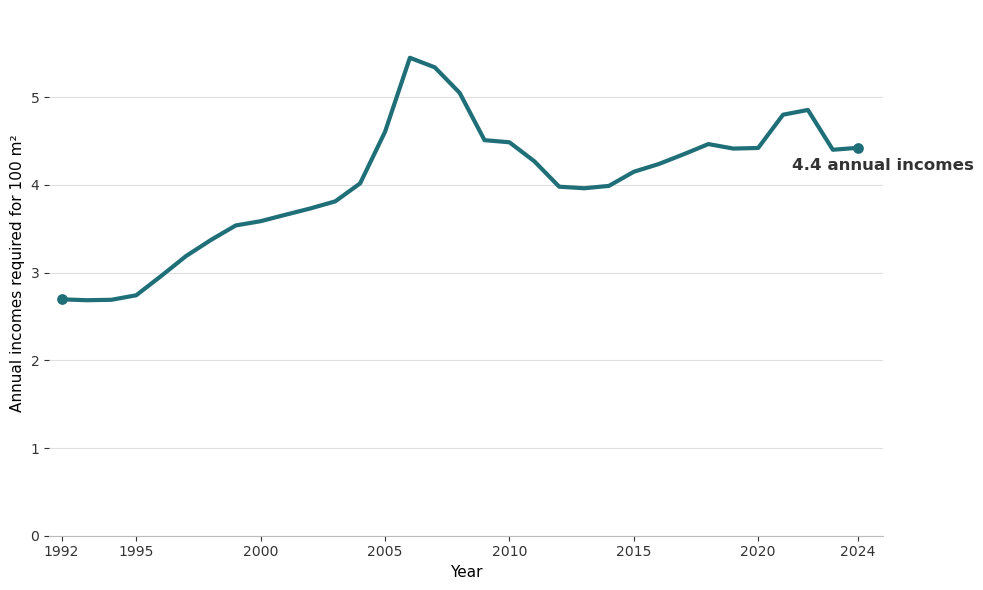

In [7]:
import matplotlib.pyplot as plt

# Colors consistent with project
afford_color = "#1F6F78"   # housing brick red
base_color = "#777777"
grid_color = "#D8D8D8"
muted_text = "#666666"
font_color = "#333333"

fig, ax = plt.subplots(figsize=(10, 6))

latest_year = plot_df["year"].max()
latest = plot_df.loc[plot_df["year"] == latest_year].iloc[0]
latest_value = latest["annual_incomes_for_100sqm"]

base_year = 1992
base_value = plot_df.loc[
    plot_df["year"] == base_year,
    "annual_incomes_for_100sqm"
].iloc[0]

# Main line
ax.plot(
    plot_df["year"],
    plot_df["annual_incomes_for_100sqm"],
    color=afford_color,
    linewidth=3,
    solid_capstyle="round",
    zorder=3
)


# Endpoint marker
ax.scatter(
    latest_year,
    latest_value,
    color=afford_color,
    s=45,
    zorder=4
)

# start marker
ax.scatter(
    base_year,
    base_value,
    color=afford_color,
    s=45,
    zorder=4
)



# Labels
label_x = 2024.35

ax.text(
    label_x - 3,
    latest_value - 0.2,
    f"{latest_value:.1f} annual incomes",
    color=font_color,
    fontsize=12,
    fontweight="bold",
    va="center",
    ha="left"
)


# Axes
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Annual incomes required for 100 m²", fontsize=11)

ax.set_xlim(plot_df["year"].min() -0.5, 2025)
ax.set_xticks([1992,1995, 2000, 2005, 2010, 2015, 2020, 2024])

ymin = 0
ymax = plot_df["annual_incomes_for_100sqm"].max() * 1.10
ax.set_ylim(ymin, ymax)

# Grid and spines
ax.grid(axis="y", color=grid_color, linewidth=0.8, alpha=0.8)
ax.grid(axis="x", visible=False)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#BBBBBB")
ax.tick_params(axis="both", labelsize=10, colors="#333333")

plt.tight_layout()
plt.show()